In [5]:
from loopr.models.unet import load_unet
from torch.utils.data import DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torch
from loopr.losses.weighted_focal import WeightedFocalDiceLoss
from loopr.training.train_unet import fit
from loopr.config.training_nn import TrainingNNConfig
from loopr.data.semantic_segmentation import get_train_transforms, get_valid_transforms,  SemanticSegmentationDataset, collate_fn
from loopr.eda.class_visualization import number_of_files_per_class

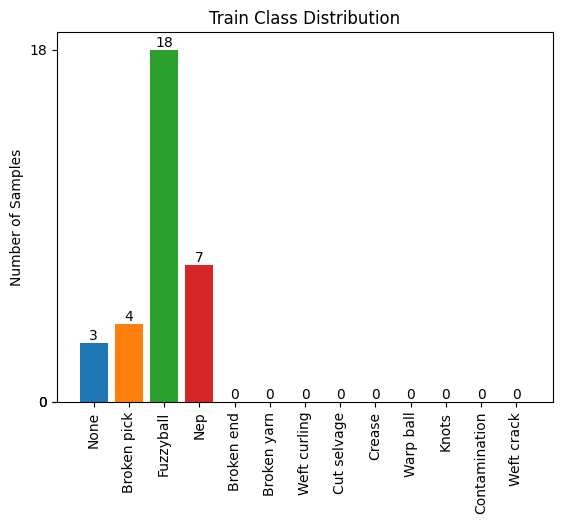

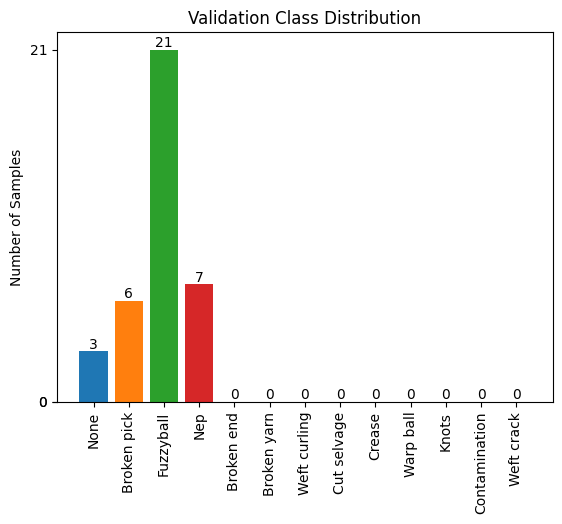

In [6]:
# Load Model
unet_model = load_unet(TrainingNNConfig.pretrained_path,gpu=True)
unet_model.train()
# Load Data
train_ds = SemanticSegmentationDataset(
    transforms=get_train_transforms(), 
    training=True,
    censor_class = {0: 4}
)
valid_ds = SemanticSegmentationDataset(
    transforms=get_valid_transforms(), 
    training=False,
    censor_class = {0: 4}
)
number_of_files_per_class(train_ds, valid_ds)

In [4]:

train_loader = DataLoader(train_ds, batch_size=TrainingNNConfig.batch_size,
                          shuffle=True, num_workers=TrainingNNConfig.num_workers,
                          collate_fn=collate_fn)

valid_loader = DataLoader(valid_ds, batch_size=TrainingNNConfig.batch_size,
                          shuffle=False, num_workers=TrainingNNConfig.num_workers,
                          collate_fn=collate_fn)
# Weight loss for imbalanced data
from collections import Counter
class_counts = Counter(train_ds.classes)
total_count = sum(list(class_counts.values()))
class_weights=[0.0001,5,5,5]
criterion = WeightedFocalDiceLoss(class_weights=class_weights)
optimizer = Adam(unet_model.parameters(), lr=TrainingNNConfig.lr, weight_decay=TrainingNNConfig.weight_decay)
scheduler = ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)


# Eğitimi başlat ve history yakala
history = fit(unet_model.cuda(), train_loader, valid_loader, optimizer, scheduler, criterion, TrainingNNConfig.device,
              num_epochs=TrainingNNConfig.epochs, early_stopping_patience=TrainingNNConfig.early_stopping_patience, save_path=TrainingNNConfig.pretrained_path)



Epoch 1/100


Train Loss: 0.2970, Dice: 0.9453
Valid Loss: 0.2760, Dice: 0.9865
✅ Best model saved at epoch 1 (dice=0.9865)

Epoch 2/100


Train Loss: 0.2904, Dice: 0.9453
Valid Loss: 0.2681, Dice: 0.9865

Epoch 3/100


Train Loss: 0.2802, Dice: 0.9531
Valid Loss: 0.1890, Dice: 0.9865

Epoch 4/100


Train Loss: 0.2814, Dice: 0.9688
Valid Loss: 0.2534, Dice: 0.9865

Epoch 5/100


...

Train Loss: 0.2355, Dice: 0.9531
Valid Loss: 0.2653, Dice: 0.9865

Epoch 48/100


Train Loss: 0.2394, Dice: 0.9688
Valid Loss: 0.2655, Dice: 0.9865

Epoch 49/100


Train Loss: 0.2476, Dice: 0.9531
Valid Loss: 0.2673, Dice: 0.9865

Epoch 50/100


Train Loss: 0.2467, Dice: 0.9688
Valid Loss: 0.2679, Dice: 0.9865

Epoch 51/100


Train Loss: 0.2386, Dice: 0.9766
Valid Loss: 0.2672, Dice: 0.9865
⏹️ Early stopping triggered.
Training finished. Best Dice = 0.9865


In [ ]:
history

In [ ]:
unet_model.eval()
import matplotlib.pyplot as plt
import numpy as np
for i,(img, mask, meta) in enumerate(train_ds):
    # if i==5:
    #     break
    # Overlay
    overlay = np.array(img)
    mask = np.repeat(np.array(mask), 3, axis=0)
    print(np.unique(mask),mask.shape)
    colors = [(255), (255), (255), (255)]  # R, G, B, Sarı
    for i in range(4):
        plt.subplot(1,7,i+2)


        # overlay[new_mask] = (0.7*overlay[new_mask] + 0.3*np.array(colors[i])).astype(np.uint8)
        plt.imshow(mask[i], cmap="gray")
        plt.title(f"Class {i+1}")
        plt.axis("off")
        

    plt.subplot(1,7,1)
    overlay -= overlay.min()
    overlay /= overlay.max()
    plt.imshow(np.transpose(overlay,(2,1,0)))
    plt.title(f"Class {i+1}")
    plt.axis("off")

    out = unet_model(torch.tensor(img[None]).cuda()).cpu().detach()
    plt.subplot(1,7,1)
    out -= out.min()
    out /= out.max()
    print(out.shape)
    out = out[0]
    out = np.transpose(out,(2,1,0))
    plt.imshow(out)
    plt.title(f"Out {i+1}")
    plt.axis("off")
    plt.show()
